<a href="https://colab.research.google.com/github/denverkim/BA_FALL2026/blob/main/LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 선형회귀 예제

In [2]:
import pandas as pd

butler = pd.read_excel('/content/butler.xlsx')
butler

,DrivingAssignment,MilesTraveled,NumberOfDeliveries,TravelTime
0,1,100,4,9.3
1,2,50,3,4.8
2,3,100,4,8.9
3,4,100,2,6.5
4,5,50,2,4.2
5,6,80,2,6.2
6,7,75,3,7.4
7,8,65,4,6.0
8,9,90,3,7.6
9,10,90,2,6.1


In [8]:
# 한글폰트 설치
!apt-get update -qq
!apt-get install -y fonts-nanum -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 122809 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.15.0-1.1ubuntu2) ...


In [8]:
import matplotlib.font_manager as fm

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'

# 폰트 등록
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

In [5]:
# 한글폰트 설정
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rc('font', family=font_name)
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스(-) 깨짐 방지

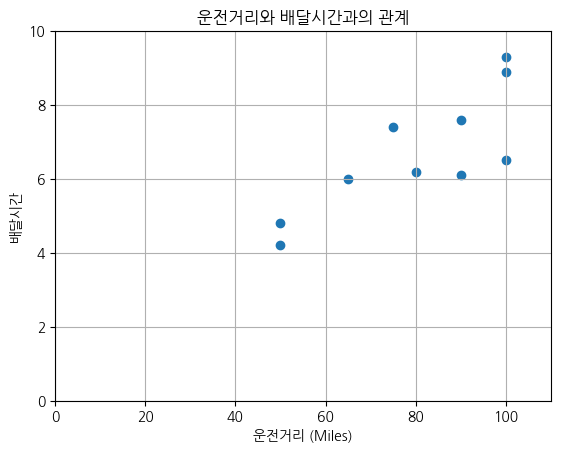

In [10]:
# 산점도
import matplotlib.pyplot as plt

plt.scatter(butler['MilesTraveled'], butler['TravelTime'])
plt.xlabel('운전거리 (Miles)')
plt.ylabel('배달시간')
plt.xlim(0, 110)
plt.ylim(0,10)
plt.grid()
plt.title('운전거리와 배달시간과의 관계')
plt.show()

In [11]:
# x and y split
y = butler['TravelTime']
x = butler['MilesTraveled']

In [12]:
# 선형 회귀분석
import statsmodels.api as sm
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             TravelTime   R-squared:                       0.664
Model:                            OLS   Adj. R-squared:                  0.622
Method:                 Least Squares   F-statistic:                     15.81
Date:                Fri, 02 Oct 2026   Prob (F-statistic):            0.00408
Time:                        07:33:27   Log-Likelihood:                -13.092
No. Observations:                  10   AIC:                             30.18
Df Residuals:                       8   BIC:                             30.79
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             1.2739      1.401      0.909      0.390      -1.956       4.504
MilesTraveled     0.0678      0.017      3.977      0.004       0.028       0.107
==============================================================================
Omnibus:                        0.694   Durbin-Watson:                   1.723
Prob(Omnibus):                  0.707   Jarque-Bera (JB):                0.623
Skew:                          -0.333   Prob(JB):                        0.732
Kurtosis:                       1.974   Cond. No.                         363.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# 배달시간 = 1.2739 + 0.0678 * 운전거리
# R-squared:	0.664, 66.4%의 설명력을 갖는 모델이다.

In [13]:
butler.columns

Index(['DrivingAssignment', 'MilesTraveled', 'NumberOfDeliveries',
       'TravelTime'],
      dtype='object')

In [15]:
# 다중 회귀분석
y = butler.TravelTime
x = butler[['MilesTraveled', 'NumberOfDeliveries']]

x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             TravelTime   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.876
Method:                 Least Squares   F-statistic:                     32.88
Date:                Fri, 02 Oct 2026   Prob (F-statistic):           0.000276
Time:                        07:40:42   Log-Likelihood:                -6.8398
No. Observations:                  10   AIC:                             19.68
Df Residuals:                       7   BIC:                             20.59
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.8687      0.952     -0.913      0.392      -3.119       1.381
MilesTraveled          0.0611      0.010      6.182      0.000       0.038       0.085
NumberOfDeliveries     0.9234      0.221      4.176      0.004       0.401       1.446
==============================================================================
Omnibus:                        0.039   Durbin-Watson:                   2.515
Prob(Omnibus):                  0.981   Jarque-Bera (JB):                0.151
Skew:                           0.074   Prob(JB):                        0.927
Kurtosis:                       2.418   Cond. No.                         435.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# 배달시간 = -0.8687 + 0.0611*운전거리 + 0.9234*배달갯수
# R-squared:	0.904, 90.4%의 설명력을 갖는 모델
# F test의 p값이 0.05보다 작아서 전체 모델은 통계적으로 유의한 모델이다.
# MilesTraveled, NumberOfDeliveries t test의 p값이 0.05보다 작아서 MilesTraveled, NumberOfDeliveries은 통계적으로 유의한 변수다.

In [18]:
# 잔차분석
y_pred = model.predict(x)
y_pred

,0
0,8.938460
1,4.958305
2,8.938460
3,7.091609
4,4.034879
5,5.868917
6,6.486670
7,6.798749
8,7.403689
9,6.480263


In [20]:
# 잔차
residual = y - y_pred
residual

,0
0,0.361540
1,-0.158305
2,-0.038460
3,-0.591609
4,0.165121
5,0.331083
6,0.913330
7,-0.798749
8,0.196311
9,-0.380263


In [22]:
# 표준잔차
import numpy as np
std_residual = residual / np.std(residual)
std_residual

,0
0,0.753954
1,-0.330128
2,-0.080204
3,-1.233740
4,0.344342
5,0.690439
6,1.904656
7,-1.665708
8,0.409387
9,-0.792999


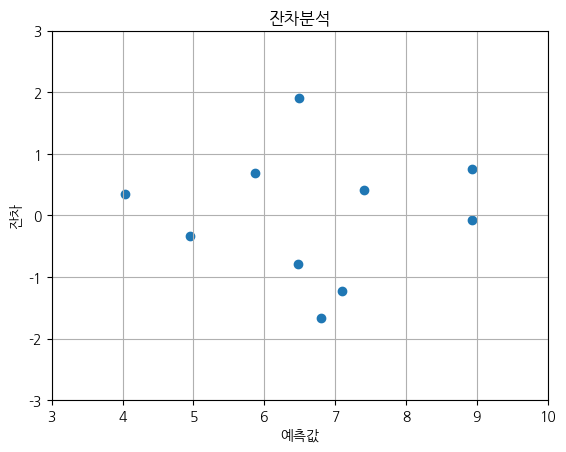

In [26]:
# 잔차 그래프
plt.scatter(y_pred, std_residual)
plt.xlabel('예측값')
plt.ylabel('잔차')
plt.title('잔차분석')
plt.ylim(-3, 3)
plt.xlim(3,10)
plt.grid()
plt.show()